# Aliasing exercises - SOLUTION

* Sample a 4000Hz sine wave at 300Hz. What frequency does it have now? Fourier transform this data to confirm.
* Sample a 4000Hz sine wave at 250Hz. What frequency does it have now? Fourier transform this data to confirm.
* Create a dataset consisting of sine waves at 150Hz, 250Hz, 350 Hz, and 450Hz (randomly choose the phase). Sample this data at 65Hz. What is the frequency content of this aliased output?

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# Copy your compute_fourier_transform function here:
def compute_fourier_transform_numpy(data_time_domain):
    return np.fft.fft(data_time_domain)

def compute_inverse_fourier_transform_numpy(data_frequency_domain):
    return np.fft.ifft(data_frequency_domain)

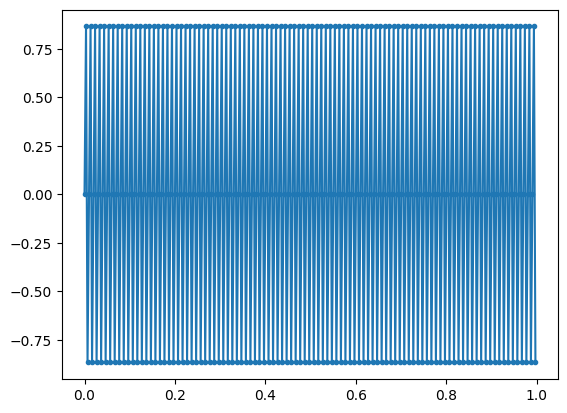

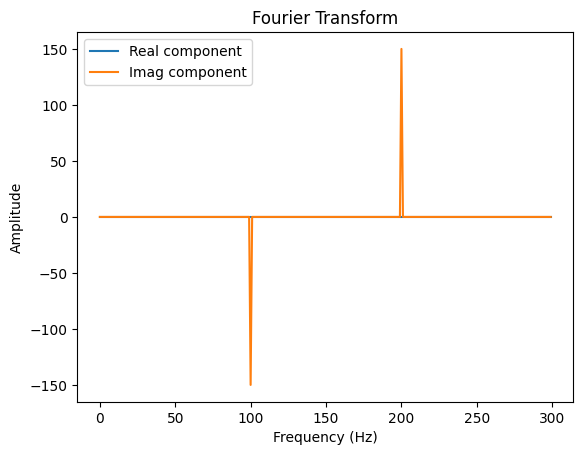

In [ ]:
# 4000Hz sine wave sampled at 300Hz (300 samples per second)
# Time array from zero to one second at 300Hz
times_ex1 = np.linspace(0,1,300, endpoint=False)
frequencies_ex1 = np.arange(300)
# Sine wave at 4000Hz sampled using time array.
omega = (4000) * (2*np.pi)
sine_wave = np.sin(omega * times_ex1)

plt.plot(times_ex1,sine_wave, marker='.')

plt.figure()
data_frequency_domain = compute_fourier_transform_numpy(sine_wave)
plt.plot(frequencies_ex1, data_frequency_domain.real)
plt.plot(frequencies_ex1, data_frequency_domain.imag)
plt.title('Fourier Transform')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.legend(['Real component','Imag component'])

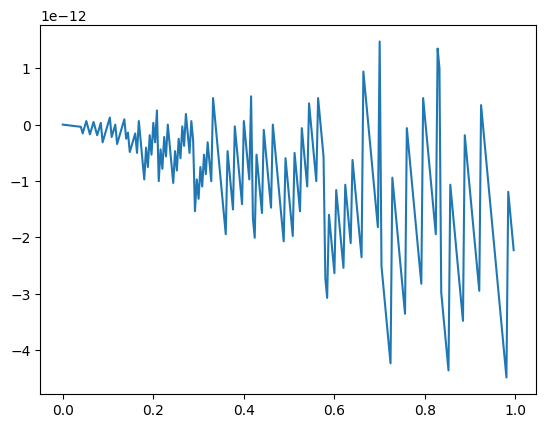

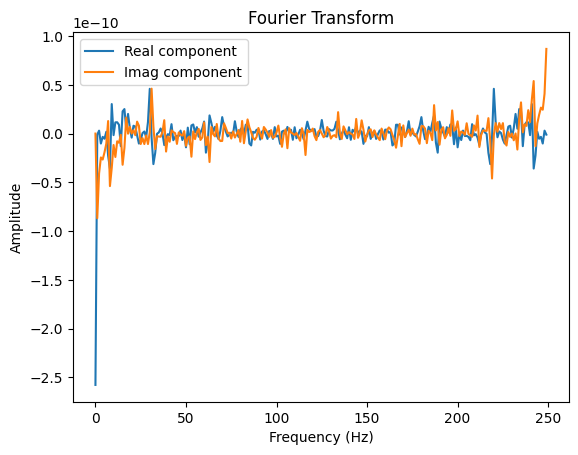

In [ ]:
# A 4000Hz wave sampled at 250Hz will always have the same value! What you see here is numerical
# noise!

times_ex2 = np.linspace(0,1,250, endpoint=False)
frequencies_ex2 = np.arange(250)
omega = (4000) * (2*np.pi)
sine_wave_2 = np.sin(omega * times_ex2)

plt.plot(times_ex2,sine_wave_2)


plt.figure()
data_frequency_domain = compute_fourier_transform_numpy(sine_wave_2)
plt.plot(frequencies_ex2, data_frequency_domain.real)
plt.plot(frequencies_ex2, data_frequency_domain.imag)
plt.title('Fourier Transform')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.legend(['Real component','Imag component'])

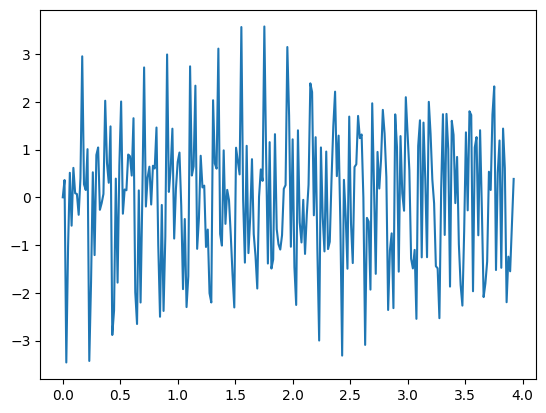

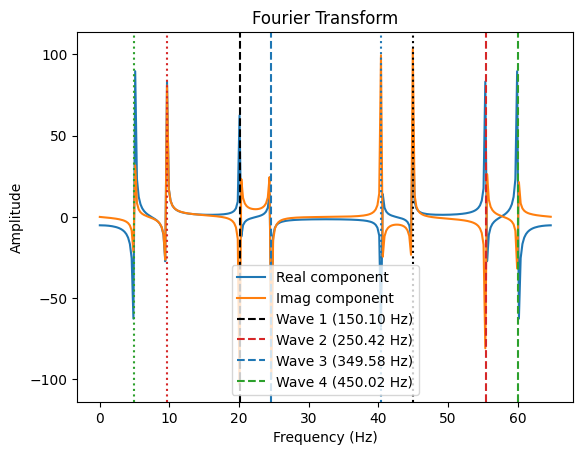

In [ ]:
# The third problem with 4 waves at different frequencies
sample_frequency = 65
times_ex3 = np.arange(256) * (1./sample_frequency)
frequencies_ex3 = np.arange(256) * sample_frequency / 256.
np.random.seed(3)

# Lets save the frequencies 
freq1 = (150 + np.random.uniform(-1, 1))
freq2 = (250 + np.random.uniform(-1, 1))
freq3 = (350 + np.random.uniform(-1, 1))
freq4 = (450 + np.random.uniform(-1, 1))
# Convert to angular frequency
omega1 = freq1 * (2*np.pi)
omega2 = freq2 * (2*np.pi)
omega3 = freq3 * (2*np.pi)
omega4 = freq4 * (2*np.pi)
# Add together the waves at this frequency
sine_waves = np.sin(omega1 * times_ex3)
sine_waves += np.sin(omega2 * times_ex3)
sine_waves += np.sin(omega3 * times_ex3)
sine_waves += np.sin(omega4 * times_ex3)

plt.plot(times_ex3,sine_waves)

plt.figure()
data_frequency_domain = compute_fourier_transform_numpy(sine_waves)
plt.plot(frequencies_ex3, data_frequency_domain.real)
plt.plot(frequencies_ex3, data_frequency_domain.imag)
# Add lines to indicate where the wave is being aliased to
# The first alias line is at true_frequency % sample_rate
# a % b means the remainder when a is divided by an ingetger multiple of b, so e.g. 150 % 65 would be 20 = 150 - 65*2
plt.axvline(freq1 % sample_frequency, linestyle='--', c='k')
plt.axvline(freq2 % sample_frequency, linestyle='--', c='tab:red')
plt.axvline(freq3 % sample_frequency, linestyle='--', c='tab:blue')
plt.axvline(freq4 % sample_frequency, linestyle='--', c='tab:green')
# There are additional lines, these are the negative frequencies this is aliased to
# To calculate these, we calculate sample_rate - true_frequency % sample rate
plt.axvline(sample_frequency - freq1 % sample_frequency, linestyle=':', c='k')
plt.axvline(sample_frequency - freq2 % sample_frequency, linestyle=':', c='tab:red')
plt.axvline(sample_frequency - freq3 % sample_frequency, linestyle=':', c='tab:blue')
plt.axvline(sample_frequency - freq4 % sample_frequency, linestyle=':', c='tab:green')

plt.title('Fourier Transform')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.legend(['Real component','Imag component', f'Wave 1 ({freq1:.2f} Hz)', f'Wave 2 ({freq2:.2f} Hz)', f'Wave 3 ({freq3:.2f} Hz)', f'Wave 4 ({freq4:.2f} Hz)'], loc='lower center')